# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types


/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

1. Identify Age-Driver Transcription Factors

Use the model to rank TFs based on their predicted ability to accelerate or reverse aging signatures in specific PBMC subtypes.
	•	Highlight TFs whose perturbation causes large positive or negative shifts in predicted age.
	•	Compare across cell types to find universal vs. cell-type-specific aging regulators.

2. Compare Aging Across Subtypes

Quantify how sensitive different PBMC subtypes are to the same TF perturbation in terms of age shift.
	•	Some cell types may be more “reversible” than others.
	•	Useful for understanding which immune compartments are more plastic with age.
3. Screen for Rejuvenation Targets

Identify TFs whose in-silico perturbation shifts aged cells toward a younger profile.
	•	Create a short list of candidate rejuvenation TFs.
	•	Cross-check with known interventions (e.g., Yamanaka factors, caloric restriction).

4. Contextualize Disease-Aging Interactions

Apply the model to PBMCs from individuals with age-related diseases (e.g., SLE, Alzheimer’s).
	•	Identify TF perturbations that reverse disease-induced age acceleration.
	•	Find disease-specific TFs that exaggerate or mitigate aging responses.

5. Build Age-Trajectory Maps

Use the predicted age shifts to construct pseudo-time trajectories showing how perturbations could reshape aging progression.
	•	Map TF-induced age “paths” across time.
	•	Reveal nonlinear dynamics or tipping points.

6. Link to Epigenetics / Accessibility Data

If you have ATAC-seq or chromatin data, use it to:
	•	Check if predicted rejuvenating TFs show increased accessibility in younger cells.
	•	Prioritize TFs that are both functional in the model and epigenetically poised.

In [2]:
if True: # single
    from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening
    from ciim.src.common import save_dir
    perturbation_mode = 'natural_aging' # 'overexpression' # 'natural_aging' for aging clock, 'overexpression' for overexpression perturbation
    par = {
        'years': 10,
        'n_donors': 1, # select only one donor for linear models
        'data_type': 'bulk',
        'version': 'v1.0',
        'reg_type': 'ridge',
        'feature_type': 'gene_expression',
        'perturbation_mode': perturbation_mode, # natural_aging, overexpression
        'perturbation_type': 'single',
        'tfs': None,  # None means all TFs
        
    }
    datasets = ['data7_allTPs_jalil'] #['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']
    cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
    df_all = wrapper_run_tf_screening(par, 
                                    n_jobs=10,
                                    cell_types=cell_types,
                                    datasets=datasets 
                                    )
    save_file=f"{save_dir}/perturbation/tf_screen_results_{perturbation_mode}.csv"
    df_all.to_csv(save_file, index=False)

/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

Processing: CD4T - data7_allTPs_jalil (natural_aging | single)
Processing: NK - data7_allTPs_jalil (natural_aging | single)
Processing: CD8T - data7_allTPs_jalil (natural_aging | single)
Processing: MONO - data7_allTPs_jalil (natural_aging | single)
Processing: B - data7_allTPs_jalil (natural_aging | single)


In [7]:
df_all['cell_type'].unique()

array(['CD8T'], dtype=object)

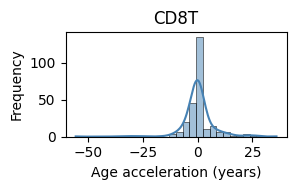

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = df_all['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = df_all[df_all['cell_type'] == cell_type].copy()
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

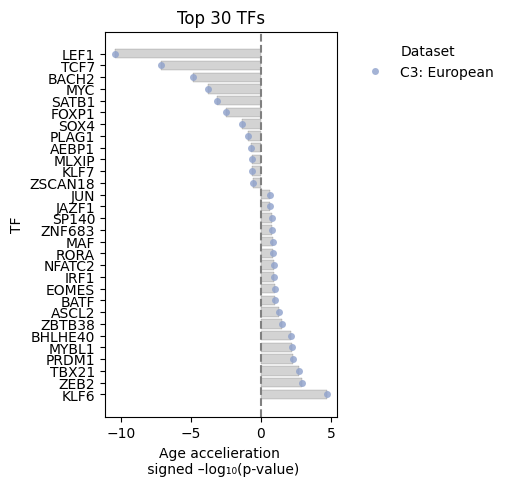

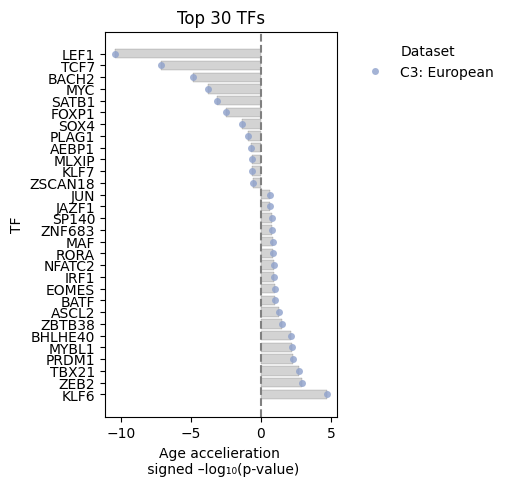

In [4]:
from ciim.src.insilico_perturbation.helper import wrapper_plot_age_acceleration_for_tf_perturbation

cell_type = 'CD8T'
features = None

perturbation_mode = 'overexpression' # 'knockdown', 'overexpression'
df_all = pd.read_csv(f"{save_dir}/perturbation/tf_screen_results_{perturbation_mode}.csv")
df_all = df_all[df_all['cell_type'] == cell_type].copy()
if features is not None:
    df_all = df_all[df_all['tf'].isin(features)].copy()


wrapper_plot_age_acceleration_for_tf_perturbation(df_all)

In [5]:
from ciim.src.insilico_perturbation.helper import perform_stat_test, plot_age_acceleration_donors
# format the data for test
cell_type = 'CD8T'
dataset = 'data12'
ctr='Unperturbed'
treatment='Perturbed'

df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
p_value, slope = perform_stat_test(df_pivot, ctr=ctr, treatment=treatment)
plot_age_acceleration_donors(df_pivot, ctr=ctr, treatment=treatment)


NameError: name 'obs_all' is not defined